In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
from air_quality_monitor.analysis import AirQualityAnalyser
from air_quality_monitor.storage import CSVStorage
from air_quality_monitor.models import AirQualityReading
from pathlib import Path

In [3]:
notebook_dir = Path().resolve()
filepath = notebook_dir.parent / "data" / "aqi_history.csv"

storage = CSVStorage(filepath, AirQualityReading)

df = storage.read()
print(df)
print(df.dtypes)

Read dtypes:
city                                   str
state                                  str
country                                str
latitude                           float64
longitude                          float64
aqi                                  int64
main_pollutant                         str
pollutant_timestamp    datetime64[us, UTC]
temperature                          int64
humidity                             int64
pressure                             int64
wind_speed                         float64
wind_direction                       int64
heat_index                         float64
weather_timestamp      datetime64[us, UTC]
collected_at           datetime64[us, UTC]
dtype: object
       city              state             country  latitude  longitude  aqi  \
0  Sarajevo  Federation of B&H  Bosnia Herzegovina       NaN        NaN   92   
1  Sarajevo  Federation of B&H  Bosnia Herzegovina       NaN        NaN   84   
2  Sarajevo  Federation of B&H  Bosnia Herzeg

In [9]:
analyser = AirQualityAnalyser(df)
df_to_print = analyser.filter_by_city("Sarajevo").get_aqi_by_date_range(end_date="2026-03-24 09:00:00+00:00")
print(df_to_print)

        pollutant_timestamp  aqi
0 2026-03-24 08:00:00+00:00   92
1 2026-03-24 09:00:00+00:00   84


C:\Users\Doug\AppData\Local\Temp\ipykernel_38788\1577399136.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


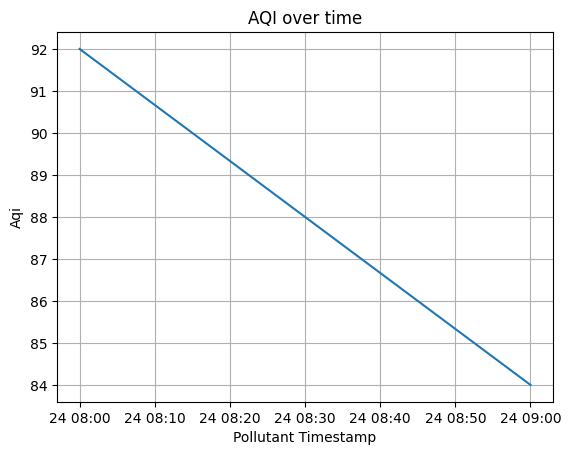

In [10]:
fig = analyser.plot_line_chart(df_to_print, x_axis="pollutant_timestamp", y_axis="aqi", title="AQI over time")
fig.show()